# **Practical 8 — Deep CNN Architectures**

**Build, Train and Compare in PyTorch**

**Architectures:** LeNet-5 • AlexNet • VGG-16 • PlacesNet • ResNet-18

### Aim
Build, inspect and compare five important CNN architectures using PyTorch.  
For each architecture, print layer shapes and parameter counts, verify selected calculations by hand, and train a scaled-down version on CIFAR-10.

### Dataset
CIFAR-10: 32×32 RGB images in 10 classes.



## **Step 0 — Setup**

The laboratory manual requires Python 3.9+, `torch`, `torchvision` and `matplotlib`.  
A CPU is sufficient for the scaled-down experiments; a GPU can make training faster.

In [ ]:
# -------------------- IMPORT LIBRARIES --------------------

import math
import time

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt


# Set random seed so that results are more reproducible
torch.manual_seed(0)


# Use GPU if CUDA is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch", torch.__version__, "| device:", device)


# ==========================================================
# FUNCTION 1: COUNT PARAMETERS
# ==========================================================

def count_params(m):
    # m.parameters() gives all trainable parameters
    # numel() gives the number of elements in each parameter tensor
    # sum() adds all parameter counts
    return sum(p.numel() for p in m.parameters())


# ==========================================================
# FUNCTION 2: TRACE THE MODEL
# ==========================================================

def trace(model, x, skip=()):

    # Put model into evaluation mode
    model.eval()

    # We are only checking the model, not training it
    # Therefore, gradients are not required
    with torch.no_grad():

        # Go through every layer of the model
        # enumerate() gives:
        # i     -> layer number
        # layer -> actual layer
        for i, layer in enumerate(model):

            # Pass the input through the current layer
            # This is the forward pass
            x = layer(x)

            # Check whether this layer is NOT in the skip list
            # If it is not skipped, print its information
            if not isinstance(layer, skip):

                # Get the name of the layer
                # Example: Conv2d, ReLU, MaxPool2d
                name = layer.__class__.__name__

                # Get the output shape after this layer
                shape = str(tuple(x.shape))

                # Print:
                # layer number
                # layer name
                # output shape
                # number of parameters
                print(
                    f"{i:2d} {name:<18s} "
                    f"{shape:<20s} "
                    f"{count_params(layer):>12,}"
                )

    # Print total number of parameters in the complete model
    print("total parameters:", f"{count_params(model):,}")


# ==========================================================
# DATA: CIFAR-10
# ==========================================================

# Create image preprocessing steps:
# 1. Convert image to PyTorch tensor
# 2. Normalize the RGB channels
tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        (0.5, 0.5, 0.5),   # Mean for R, G, B
        (0.5, 0.5, 0.5)    # Standard deviation for R, G, B
    )
])


# Load CIFAR-10 training dataset
# train=True means use training images
# download=True downloads it if it is not already available
# transform=tf applies our preprocessing
train_set = torchvision.datasets.CIFAR10(
    "data",
    train=True,
    download=True,
    transform=tf
)


# Load CIFAR-10 test dataset
# train=False means use test images
test_set = torchvision.datasets.CIFAR10(
    "data",
    train=False,
    download=True,
    transform=tf
)


# ==========================================================
# FUNCTION 3: CONVERT DATASET INTO TENSORS
# ==========================================================

def load(ds):

    # Go through the dataset and separate:
    # xs -> images
    # ys -> labels
    xs, ys = zip(
        *[ds[i] for i in range(len(ds))]
    )
# ds[0] → (image0, 3)
# ds[1] → (image1, 7)
# ds[2] → (image2, 1)
# So each item has:  image + label

# zip() goups elements acc to their positions
# It produces approximately:

# (image0, image1, image2)
# (3,      7,      1)

# * says take the items inside list pass them speratly and not as list



    # Stack all images into one tensor
    # Convert all labels into a tensor
    return torch.stack(xs), torch.tensor(ys)


# Use only the first 10,000 training images
# Xtr -> training images
# Ytr -> training labels
Xtr, Ytr = load(
    torch.utils.data.Subset(
        train_set,
        range(10000)
    )
)


# Use only the first 2,000 test images
# Xte -> test images
# Yte -> test labels
Xte, Yte = load(
    torch.utils.data.Subset(
        test_set,
        range(2000)
    )
)


# Print the shape of training and testing data
# Expected:
# train -> (10000, 3, 32, 32)
# test  -> (2000, 3, 32, 32)
print(
    "train", tuple(Xtr.shape),
    "| test", tuple(Xte.shape)
)


# ==========================================================
# FUNCTION 4: CALCULATE ACCURACY
# ==========================================================

def accuracy(model):

    # Put model into evaluation mode
    model.eval()

    # Find whether the model is on CPU or GPU
    dev = next(model.parameters()).device

    # Counter for correct predictions
    hits = 0

    # No gradients are needed during testing
    with torch.no_grad():

        # Test 500 images at a time
        for i in range(0, len(Xte), 500):

            # Send 500 test images through the model
            # argmax(1) selects the class with the highest score
            # cpu() moves predictions back to CPU
            pred = model(
                Xte[i:i+500].to(dev)
            ).argmax(1).cpu()

            # Compare predictions with the actual labels
            # Count how many predictions are correct
            hits += (
                pred == Yte[i:i+500]
            ).sum().item()

    # Accuracy = correct predictions / total test images
    return hits / len(Xte)


# Dictionary to store results of all CNNs
results = {}


# ==========================================================
# FUNCTION 5: TRAIN THE MODEL
# ==========================================================

def fit(name, model, epochs=4):

    # Move the model to CPU or GPU
    model.to(device)

    # Create Adam optimizer
    # lr = learning rate = 0.001
    opt = torch.optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    # Record starting time
    # Used later to calculate training time
    start = time.time()


    # Repeat training for the specified number of epochs
    for ep in range(epochs):

        # Put model into training mode
        model.train()

        # Create a random ordering of training images
        # This shuffles the training data
        order = torch.randperm(len(Xtr))


        # Process training data in batches of 64
        for i in range(0, len(order), 64):

            # Select 64 image indices
            idx = order[i:i+64]


            # Clear gradients from previous batch
            opt.zero_grad()


            # ---------------- FORWARD PASS ----------------

            # Send the batch through the CNN
            # Compare predictions with correct labels
            # Cross-entropy calculates the loss
            loss = F.cross_entropy(
                model(Xtr[idx].to(device)),
                Ytr[idx].to(device)
            )


            # ---------------- BACKPROPAGATION ----------------

            # Calculate gradients of the loss
            loss.backward()


            # ---------------- UPDATE WEIGHTS ----------------

            # Adam uses the gradients to update
            # the model's weights and biases
            opt.step()


        # After one complete epoch,
        # test the model on the 2,000 test images
        acc = accuracy(model)


        # Print test accuracy for this epoch
        print(
            f"{name:<15s} "
            f"epoch {ep+1}: "
            f"test accuracy {acc:.3f}"
        )


    # Store final results of this model
    results[name] = {
        # Total number of parameters
        "params": count_params(model),

        # Total training time in seconds
        "seconds": round(time.time() - start),
        # current time - start time

        # Final test accuracy
        "acc": acc
    }

PyTorch 2.11.0+cu128 | device: cuda


100%|██████████| 170M/170M [11:51<00:00, 240kB/s]


train (10000, 3, 32, 32) | test (2000, 3, 32, 32)


# **Part 1 — LeNet-5**

### Aim
Build LeNet-5, verify the output shape after every layer, calculate selected parameter counts by hand, and train it on CIFAR-10.

LeNet-5 uses convolution, subsampling and fully connected layers. The original architecture was designed for handwritten digit recognition. Here the first convolution accepts 3 channels because CIFAR-10 contains RGB images.

In [ ]:
# ==========================================================
# LE-NET-5
# ==========================================================

# Function to create the LeNet-5 architecture
# num_classes = number of output classes
# CIFAR-10 has 10 classes, so default is 10
def make_lenet(num_classes=10):

    # nn.Sequential applies the layers one after another
    return nn.Sequential(

        # --------------------------------------------------
        # C1: Convolution layer
        # Input:  3 × 32 × 32
        # Output: 6 × 28 × 28
        #
        # 3  = input channels (RGB)
        # 6  = number of filters
        # 5  = kernel size (5 × 5)
        # --------------------------------------------------
        nn.Conv2d(3, 6, 5),

        # Activation function
        nn.Tanh(),


        # --------------------------------------------------
        # S2: Average Pooling
        # 2 × 2 pooling reduces spatial dimensions by half
        #
        # 28 × 28 → 14 × 14
        # --------------------------------------------------
        nn.AvgPool2d(2),


        # --------------------------------------------------
        # C3: Second convolution
        #
        # Input:  6 × 14 × 14
        # Output: 16 × 10 × 10
        #
        # 6  = input channels
        # 16 = number of filters
        # 5  = kernel size
        # --------------------------------------------------
        nn.Conv2d(6, 16, 5),

        # Activation function
        nn.Tanh(),


        # --------------------------------------------------
        # S4: Average Pooling
        #
        # 10 × 10 → 5 × 5
        # --------------------------------------------------
        nn.AvgPool2d(2),


        # --------------------------------------------------
        # C5: Third convolution
        #
        # Input:  16 × 5 × 5
        # Output: 120 × 1 × 1
        #
        # 16  = input channels
        # 120 = number of filters
        # 5   = kernel size
        # --------------------------------------------------
        nn.Conv2d(16, 120, 5),

        # Activation function
        nn.Tanh(),


        # --------------------------------------------------
        # Flatten
        #
        # Converts:
        # 120 × 1 × 1
        #
        # into:
        # 120
        #
        # Needed before passing data to Linear layers
        # --------------------------------------------------
        nn.Flatten(),


        # --------------------------------------------------
        # F6: Fully connected layer
        #
        # 120 input values → 84 output values
        # --------------------------------------------------
        nn.Linear(120, 84),

        # Activation function
        nn.Tanh(),


        # --------------------------------------------------
        # Final fully connected layer
        #
        # 84 → 10
        #
        # Each of the 10 outputs represents one CIFAR-10 class
        # These are raw class scores (logits)
        # --------------------------------------------------
        nn.Linear(84, num_classes)
    )


# ==========================================================
# CREATE LENET-5
# ==========================================================

# Create a LeNet model
# num_classes defaults to 10
lenet = make_lenet()


# ==========================================================
# TRACE THE MODEL
# ==========================================================

# Create a dummy input image:
# 1  = batch size
# 3  = RGB channels
# 32 = height
# 32 = width
#
# torch.zeros() creates an image filled with zeros.
#
# skip=(nn.Tanh,) means:
# Don't print the Tanh layers in the trace output.
trace(
    lenet,
    torch.zeros(1, 3, 32, 32),
    skip=(nn.Tanh,)
)

 0 Conv2d             (1, 6, 28, 28)                456
 2 AvgPool2d          (1, 6, 14, 14)                  0
 3 Conv2d             (1, 16, 10, 10)             2,416
 5 AvgPool2d          (1, 16, 5, 5)                   0
 6 Conv2d             (1, 120, 1, 1)             48,120
 8 Flatten            (1, 120)                        0
 9 Linear             (1, 84)                    10,164
11 Linear             (1, 10)                       850
total parameters: 62,006


### Expected parameter checks

- C1: `(5×5×3 + 1) × 6 = 456`
- C3: `(5×5×6 + 1) × 16 = 2,416`
- Total parameters: **62,006**

The dense equivalent of C1 would need about **14.5 million** parameters, showing the effect of local receptive fields and weight sharing.

In [ ]:
print("C1 by hand:", (5*5*3 + 1) * 6)
print("C3 by hand:", (5*5*6 + 1) * 16)
print(
    "dense equivalent of C1:",
    f"{(32*32*3 + 1) * 6*28*28:,}"
)

C1 by hand: 456
C3 by hand: 2416
dense equivalent of C1: 14,455,392


In [ ]:
fit("LeNet-5", lenet)

LeNet-5         epoch 1: test accuracy 0.351
LeNet-5         epoch 2: test accuracy 0.378
LeNet-5         epoch 3: test accuracy 0.403
LeNet-5         epoch 4: test accuracy 0.421


### Ready to Explain

**1. Output-size formula:** H_out = ⌊(H_in + 2P − K)/S⌋ + 1
- C1: (32 + 0 − 5)/1 + 1 = **28**, so 32×32 becomes 28×28.
- C5: the input is 5×5 and the kernel is 5×5, so (5 − 5)/1 + 1 = **1**. The kernel covers the whole map, so it collapses to 1×1.

**2. Gap between 456 and 14,455,392:**
- C1 uses only 6 small 5×5×3 kernels, reused at every position (weight sharing): (75 + 1) × 6 = **456**.
- A dense layer would connect all 3,072 inputs (+1 bias) to each of the 6×28×28 = 4,704 outputs: 3,073 × 4,704 = **14,455,392**.
- Local receptive fields and weight sharing cut the parameters by about 30,000 times.

# **Part 2 — AlexNet**

### Aim
Build full-size AlexNet, inspect the parameter distribution, verify Conv1 by hand, and train a scaled-down **AlexNet-lite** on CIFAR-10.

AlexNet introduced several important practices including ReLU activations, dropout, data augmentation and GPU training. The original architecture used 227×227 colour images and a large fully connected head.

In [ ]:
# ==========================================================
# ALEXNET
# ==========================================================

def make_alexnet(num_classes=1000):
    # num_classes = number of output classes
    # Original AlexNet was designed for ImageNet → 1000 classes

    return nn.Sequential(

        # --------------------------------------------------
        # C1: First Convolution
        #
        # Input:
        # 3 × 227 × 227
        # 3 = RGB channels
        #
        # 96 = number of filters
        # 11 = filter size → 11 × 11
        # stride = 4
        #
        # Output:
        # 96 × 55 × 55
        # --------------------------------------------------
        nn.Conv2d(3, 96, 11, stride=4),

        # Activation function
        nn.ReLU(),


        # --------------------------------------------------
        # Pooling 1
        #
        # Pool size = 3 × 3
        # Stride = 2
        #
        # 55 × 55 → 27 × 27
        #
        # Number of channels remains 96
        # --------------------------------------------------
        nn.MaxPool2d(3, 2),


        # --------------------------------------------------
        # C2: Second Convolution
        #
        # Input:
        # 96 × 27 × 27
        #
        # 256 = number of filters
        # 5 = filter size → 5 × 5
        # padding = 2
        #
        # Padding keeps spatial size the same:
        # 27 × 27 → 27 × 27
        # --------------------------------------------------
        nn.Conv2d(96, 256, 5, padding=2),

        nn.ReLU(),


        # --------------------------------------------------
        # Pooling 2
        #
        # Pool size = 3 × 3
        # Stride = 2
        #
        # 27 × 27 → 13 × 13
        # --------------------------------------------------
        nn.MaxPool2d(3, 2),


        # --------------------------------------------------
        # C3: Third Convolution
        #
        # Input:
        # 256 × 13 × 13
        #
        # 384 filters
        # Filter size = 3 × 3
        # Padding = 1
        #
        # 13 × 13 → 13 × 13
        # --------------------------------------------------
        nn.Conv2d(256, 384, 3, padding=1),

        nn.ReLU(),


        # --------------------------------------------------
        # C4: Fourth Convolution
        #
        # Input:
        # 384 × 13 × 13
        #
        # 384 filters
        # Filter size = 3 × 3
        # Padding = 1
        #
        # Output:
        # 384 × 13 × 13
        # --------------------------------------------------
        nn.Conv2d(384, 384, 3, padding=1),

        nn.ReLU(),


        # --------------------------------------------------
        # C5: Fifth Convolution
        #
        # Input:
        # 384 × 13 × 13
        #
        # 256 filters
        # Filter size = 3 × 3
        # Padding = 1
        #
        # Output:
        # 256 × 13 × 13
        # --------------------------------------------------
        nn.Conv2d(384, 256, 3, padding=1),

        nn.ReLU(),


        # --------------------------------------------------
        # Pooling 3
        #
        # Pool size = 3 × 3
        # Stride = 2
        #
        # 13 × 13 → 6 × 6
        #
        # Output:
        # 256 × 6 × 6
        # --------------------------------------------------
        nn.MaxPool2d(3, 2),


        # --------------------------------------------------
        # Flatten
        #
        # 256 × 6 × 6
        #
        # = 256 × 36
        # = 9216
        #
        # Converts the feature maps into one vector.
        # --------------------------------------------------
        nn.Flatten(),


        # --------------------------------------------------
        # Fully Connected Layer 1
        #
        # 9216 → 4096
        # --------------------------------------------------
        nn.Dropout(0.5),

        nn.Linear(9216, 4096),

        nn.ReLU(),


        # --------------------------------------------------
        # Fully Connected Layer 2
        #
        # 4096 → 4096
        # --------------------------------------------------
        nn.Dropout(0.5),

        nn.Linear(4096, 4096),

        nn.ReLU(),


        # --------------------------------------------------
        # Final Classification Layer
        #
        # 4096 → 1000 classes
        # --------------------------------------------------
        nn.Linear(4096, num_classes)
    )


# ==========================================================
# CREATE ALEXNET
# ==========================================================

alexnet = make_alexnet()


# ==========================================================
# TRACE ALEXNET
# ==========================================================

trace(
    alexnet,

    # Dummy RGB image
    # 1 = batch size
    # 3 = RGB channels
    # 227 × 227 = image size
    torch.zeros(1, 3, 227, 227),

    # Don't print ReLU and Dropout in the trace
    skip=(nn.ReLU, nn.Dropout)
)

 0 Conv2d             (1, 96, 55, 55)            34,944
 2 MaxPool2d          (1, 96, 27, 27)                 0
 3 Conv2d             (1, 256, 27, 27)          614,656
 5 MaxPool2d          (1, 256, 13, 13)                0
 6 Conv2d             (1, 384, 13, 13)          885,120
 8 Conv2d             (1, 384, 13, 13)        1,327,488
10 Conv2d             (1, 256, 13, 13)          884,992
12 MaxPool2d          (1, 256, 6, 6)                  0
13 Flatten            (1, 9216)                       0
15 Linear             (1, 4096)              37,752,832
18 Linear             (1, 4096)              16,781,312
20 Linear             (1, 1000)               4,097,000
total parameters: 62,378,344


In [ ]:
# Calculate the total number of parameters
# in all Convolution (Conv2d) layers of AlexNet
conv_p = sum(
    count_params(l)          # Count parameters in this layer
    for l in alexnet         # Go through every layer in AlexNet
    if isinstance(l, nn.Conv2d)  # Keep only Conv2d layers
)


# Calculate the total number of parameters
# in all Fully Connected (Linear) layers
fc_p = sum(
    count_params(l)          # Count parameters in this layer
    for l in alexnet         # Go through every layer
    if isinstance(l, nn.Linear)  # Keep only Linear layers
)


# Print the results
print(
    f"conv {conv_p:,} fc {fc_p:,} "

    # Calculate what percentage of all Conv + FC parameters
    # belong to the fully connected layers
    #
    # Example:
    # fc_p / total_parameters = 0.90
    # :.1% converts 0.90 → 90.0%
    f"fc share {fc_p / (conv_p + fc_p):.1%}"
)


# Manually calculate the parameters and output size
# of the FIRST convolution layer
print(
    "Conv1 by hand:",

    # Conv1:
    # Input channels = 3 (RGB)
    # Filter size = 11 × 11
    # Number of filters = 96
    #
    # Parameters in ONE filter:
    # 11 × 11 × 3 = 363 weights
    #
    # + 1 bias
    #
    # Therefore:
    # (11 × 11 × 3 + 1) × 96
    # = parameters in all 96 filters
    (11*11*3 + 1) * 96,


    "| size",


    # Calculate output spatial size of Conv1
    #
    # Formula:
    # Output = (H - K + 2P) / S + 1
    #
    # Here:
    # H = 227
    # K = 11
    # P = 0
    # S = 4
    #
    # Therefore:
    # (227 - 11) / 4 + 1
    #
    # // means integer/floor division
    (227 - 11) // 4 + 1
)

conv 3,747,200 fc 58,631,144 fc share 94.0%
Conv1 by hand: 34944 | size 55


In [ ]:
def make_alexnet_lite(num_classes=10):
    # Create a smaller version of AlexNet
    # CIFAR-10 has 10 classes

    return nn.Sequential(

        # --------------------------------------------------
        # C1
        # Input:  3 × 32 × 32
        # 32 filters, each 3×3
        # padding=1 keeps size 32×32
        #
        # Output: 32 × 32 × 32
        # --------------------------------------------------
        nn.Conv2d(3, 32, 3, padding=1),
        nn.ReLU(),

        # 2×2 pooling
        # 32 × 32 → 16 × 16
        nn.MaxPool2d(2),


        # --------------------------------------------------
        # C2
        # Input: 32 × 16 × 16
        # 64 filters of 3×3
        #
        # Output: 64 × 16 × 16
        # --------------------------------------------------
        nn.Conv2d(32, 64, 3, padding=1),
        nn.ReLU(),

        # 2×2 pooling
        # 16 × 16 → 8 × 8
        nn.MaxPool2d(2),


        # --------------------------------------------------
        # C3
        # Input: 64 × 8 × 8
        # 96 filters of 3×3
        #
        # Output: 96 × 8 × 8
        # --------------------------------------------------
        nn.Conv2d(64, 96, 3, padding=1),
        nn.ReLU(),


        # --------------------------------------------------
        # C4
        # Input: 96 × 8 × 8
        # 96 filters of 3×3
        #
        # Output: 96 × 8 × 8
        # --------------------------------------------------
        nn.Conv2d(96, 96, 3, padding=1),
        nn.ReLU(),


        # --------------------------------------------------
        # C5
        # Input: 96 × 8 × 8
        # 64 filters of 3×3
        #
        # Output: 64 × 8 × 8
        # --------------------------------------------------
        nn.Conv2d(96, 64, 3, padding=1),
        nn.ReLU(),

        # 2×2 pooling
        # 8 × 8 → 4 × 4
        nn.MaxPool2d(2),


        # --------------------------------------------------
        # Flatten
        #
        # 64 × 4 × 4
        # = 64 × 16
        # = 1024
        #
        # Converts feature maps into a 1D vector
        # --------------------------------------------------
        nn.Flatten(),


        # --------------------------------------------------
        # Fully Connected Layer
        #
        # 1024 → 256
        # --------------------------------------------------
        nn.Dropout(0.5),
        nn.Linear(1024, 256),
        nn.ReLU(),


        # --------------------------------------------------
        # Fully Connected Layer
        #
        # 256 → 256
        # --------------------------------------------------
        nn.Dropout(0.5),
        nn.Linear(256, 256),
        nn.ReLU(),


        # --------------------------------------------------
        # Final Classification Layer
        #
        # 256 → 10
        # CIFAR-10 has 10 classes
        # --------------------------------------------------
        nn.Linear(256, num_classes)
    )


# Create the AlexNet-lite model
alexnet_lite = make_alexnet_lite()


# Count and print the total trainable parameters
print("parameters:", f"{count_params(alexnet_lite):,}")


# Train the model using the common training function
fit("AlexNet-lite", alexnet_lite)

parameters: 543,946
AlexNet-lite    epoch 1: test accuracy 0.295
AlexNet-lite    epoch 2: test accuracy 0.388
AlexNet-lite    epoch 3: test accuracy 0.448
AlexNet-lite    epoch 4: test accuracy 0.475


### Ready to Explain

**1. Why the FC head dominates:**
- Convolution weights are shared across positions, but a fully connected layer has one weight for every input–output pair.
- The flattened 9,216 values connect to 4,096 units. **Linear(9216, 4096)** is the biggest culprit with 37.75M parameters.
- FC layers hold 58.6M of 62.4M weights (**94%**); the convolutions hold only 3.7M.

**2. ReLU and dropout:**
- **ReLU:** the gradient is exactly 1 for positive inputs and it does not saturate like tanh, so deep networks train faster.
- **Dropout:** randomly switches off 50% of units during training, so units cannot depend on each other. This reduces overfitting, similar to averaging many sub-networks.

**3. AlexNet-lite (543,946 parameters) vs AlexNet (62.4M), about 115× fewer:**
- **Kept:** 5 convolutions, 3 poolings, 3 FC layers, ReLU and dropout.
- **Changed:** 32×32 input instead of 227×227; small 3×3 stride-1 convolutions instead of 11×11 stride 4; 2×2 pooling; fewer filters; FC width 256 instead of 4096; 10 outputs instead of 1000.
- FC layers still hold about 61% of the weights.

# **Part 3 — VGG-16**

### Aim
Build VGG-16 using repeated 3×3 convolution blocks. Compare two 3×3 convolutions with one 5×5 convolution and calculate the receptive field of stacked 3×3 layers.

VGG uses 3×3 convolutions with stride 1 and padding 1. Pooling changes the resolution, while the channel count grows across blocks.

In [ ]:
def vgg_block(c_in, c_out, n_convs, bn=False):
    # c_in    = number of input channels
    # c_out   = number of filters in each convolution
    # n_convs = number of convolution layers in this block
    # bn      = whether to use Batch Normalization

    layers = []
    # Empty list to store all layers of the block

    for i in range(n_convs):
        # Repeat the convolution n_convs times

        layers.append(
            nn.Conv2d(
                c_in if i == 0 else c_out,
                # First convolution:
                # input channels = c_in
                #
                # Later convolutions:
                # input channels = c_out

                c_out,
                # Number of filters = c_out

                3,
                # Filter/kernel size = 3×3

                padding=1
                # Padding = 1
                # Keeps height and width unchanged
            )
        )

        if bn:
            # If Batch Normalization is enabled,
            # add BatchNorm after the convolution

            layers.append(nn.BatchNorm2d(c_out))

        # Add ReLU activation after every convolution
        layers.append(nn.ReLU())

    # Add 2×2 Max Pooling at the end of every block
    # Stride = 2
    # Therefore height and width are halved
    layers.append(nn.MaxPool2d(2, 2))

    # Combine all layers in this block
    return nn.Sequential(*layers)


def make_vgg16(num_classes=1000):
    # Create the complete VGG-16 network
    # Original VGG-16 was designed for ImageNet
    # ImageNet has 1000 classes

    return nn.Sequential(

        # Block 1:
        # 3 input channels → 64 filters
        # 2 convolution layers
        # Then 2×2 pooling
        #
        # 3×224×224
        # → 64×224×224
        # → 64×224×224
        # → 64×112×112
        vgg_block(3, 64, 2),

        # Block 2:
        # 64 input channels → 128 filters
        # 2 convolution layers
        # Then pooling
        #
        # 64×112×112
        # → 128×112×112
        # → 128×112×112
        # → 128×56×56
        vgg_block(64, 128, 2),

        # Block 3:
        # 128 input channels → 256 filters
        # 3 convolution layers
        # Then pooling
        #
        # 128×56×56
        # → 256×56×56
        # → 256×56×56
        # → 256×56×56
        # → 256×28×28
        vgg_block(128, 256, 3),

        # Block 4:
        # 256 input channels → 512 filters
        # 3 convolution layers
        # Then pooling
        #
        # 256×28×28
        # → 512×28×28
        # → 512×28×28
        # → 512×28×28
        # → 512×14×14
        vgg_block(256, 512, 3),

        # Block 5:
        # 512 input channels → 512 filters
        # 3 convolution layers
        # Then pooling
        #
        # 512×14×14
        # → 512×14×14
        # → 512×14×14
        # → 512×14×14
        # → 512×7×7
        vgg_block(512, 512, 3),

        # Convert 3D feature maps into a 1D vector
        #
        # 512 × 7 × 7 = 25,088
        nn.Flatten(),

        # Fully connected layer
        # 25,088 inputs → 4,096 neurons
        nn.Linear(25088, 4096),

        # Activation
        nn.ReLU(),

        # Drop 50% of neurons during training
        nn.Dropout(0.5),

        # Fully connected layer
        # 4,096 → 4,096
        nn.Linear(4096, 4096),

        nn.ReLU(),

        nn.Dropout(0.5),

        # Final classification layer
        # 4,096 → 1,000 classes
        nn.Linear(4096, num_classes)
    )


# Create the VGG-16 model
vgg16 = make_vgg16()


# Trace the model using a dummy RGB image
#
# 1 = batch size
# 3 = RGB channels
# 224 × 224 = image size
#
# ReLU and Dropout are skipped only from the printed trace
# They are still part of the actual network.
trace(
    vgg16,
    torch.zeros(1, 3, 224, 224),
    skip=(nn.ReLU, nn.Dropout)
)

 0 Sequential         (1, 64, 112, 112)          38,720
 1 Sequential         (1, 128, 56, 56)          221,440
 2 Sequential         (1, 256, 28, 28)        1,475,328
 3 Sequential         (1, 512, 14, 14)        5,899,776
 4 Sequential         (1, 512, 7, 7)          7,079,424
 5 Flatten            (1, 25088)                      0
 6 Linear             (1, 4096)             102,764,544
 9 Linear             (1, 4096)              16,781,312
12 Linear             (1, 1000)               4,097,000
total parameters: 138,357,544


In [ ]:
# Number of input and output channels
C = 64


# --------------------------------------------------
# ONE 5×5 CONVOLUTION
# --------------------------------------------------

# Create one convolution layer:
# 64 input channels
# 64 filters
# Each filter is 5×5
# Padding = 2 keeps height and width unchanged
one_5x5 = count_params(
    nn.Conv2d(C, C, 5, padding=2)
)


# --------------------------------------------------
# TWO 3×3 CONVOLUTIONS
# --------------------------------------------------

# Create two consecutive 3×3 convolution layers
two_3x3 = count_params(
    nn.Sequential(

        # First 3×3 convolution
        # 64 input channels → 64 output channels
        nn.Conv2d(C, C, 3, padding=1),

        # ReLU has no trainable parameters
        nn.ReLU(),

        # Second 3×3 convolution
        # 64 input channels → 64 output channels
        nn.Conv2d(C, C, 3, padding=1)
    )
)


# Print parameters of one 5×5 convolution
print(f"one 5x5 : {one_5x5:,}")


# Print parameters of two 3×3 convolutions
print(f"two 3x3 : {two_3x3:,}")


# Calculate percentage of parameters saved
#
# (parameters of 5×5 - parameters of two 3×3)
# ------------------------------------------------
#          parameters of 5×5
#
# × 100 gives percentage
print(
    f"saving : {100 * (one_5x5 - two_3x3) / one_5x5:.1f}%"
)


# --------------------------------------------------
# RECEPTIVE FIELD
# --------------------------------------------------

# Initially:
# Receptive field = 1×1
# Jump between neighboring pixels = 1
r, j = 1, 1


# Check receptive field after 1, 2 and 3 convolutions
for n in range(1, 4):

    # Calculate new receptive field
    #
    # For a 3×3 convolution:
    # kernel size = 3
    #
    # r_new = r_old + (3 - 1) × jump
    r = r + (3 - 1) * j

    # Stride = 1, so jump remains unchanged
    j = j * 1

    # Print the receptive field
    print(
        f"{n} conv(s): receptive field {r}x{r}"
    )

one 5x5 : 102,464
two 3x3 : 73,856
saving : 27.9%
1 conv(s): receptive field 3x3
2 conv(s): receptive field 5x5
3 conv(s): receptive field 7x7


In [ ]:
def make_vgg_lite(num_classes=10):
    # Create a smaller VGG-16 for CIFAR-10
    # CIFAR-10 has 10 classes

    return nn.Sequential(

        # -----------------------------------------------
        # Block 1
        # 3 input channels → 16 filters
        # 2 convolution layers
        # Each filter = 3×3
        # BatchNorm is enabled
        # MaxPool: 32×32 → 16×16
        # -----------------------------------------------
        vgg_block(3, 16, 2, bn=True),


        # -----------------------------------------------
        # Block 2
        # 16 input channels → 32 filters
        # 2 convolution layers
        # Each filter = 3×3
        # MaxPool: 16×16 → 8×8
        # -----------------------------------------------
        vgg_block(16, 32, 2, bn=True),


        # -----------------------------------------------
        # Block 3
        # 32 input channels → 64 filters
        # 3 convolution layers
        # Each filter = 3×3
        # MaxPool: 8×8 → 4×4
        # -----------------------------------------------
        vgg_block(32, 64, 3, bn=True),


        # -----------------------------------------------
        # Block 4
        # 64 input channels → 128 filters
        # 3 convolution layers
        # Each filter = 3×3
        # MaxPool: 4×4 → 2×2
        # -----------------------------------------------
        vgg_block(64, 128, 3, bn=True),


        # -----------------------------------------------
        # Block 5
        # 128 input channels → 128 filters
        # 3 convolution layers
        # Each filter = 3×3
        # MaxPool: 2×2 → 1×1
        # -----------------------------------------------
        vgg_block(128, 128, 3, bn=True),


        # Convert:
        # 128 × 1 × 1 → 128
        nn.Flatten(),


        # Fully connected layer
        # 128 → 256
        nn.Linear(128, 256),
        nn.ReLU(),

        # Drop 50% neurons during training
        nn.Dropout(0.5),


        # Fully connected layer
        # 256 → 256
        nn.Linear(256, 256),
        nn.ReLU(),

        nn.Dropout(0.5),


        # Final classification layer
        # 256 → 10 CIFAR-10 classes
        nn.Linear(256, num_classes)
    )


# Create the VGG-lite model
vgg_lite = make_vgg_lite()


# Count and print the total number of parameters
print("parameters:", f"{count_params(vgg_lite):,}")


# Train the model using the common training function
fit("VGG-16-lite", vgg_lite)

parameters: 1,024,282
VGG-16-lite     epoch 1: test accuracy 0.239
VGG-16-lite     epoch 2: test accuracy 0.262
VGG-16-lite     epoch 3: test accuracy 0.340
VGG-16-lite     epoch 4: test accuracy 0.357


### Ready to Explain

**1. Three 3×3 vs one 7×7:**
- Both see a **7×7** region (my printout: 3 → 5 → 7).
- Parameters (C channels in and out): three 3×3 layers cost 27C², one 7×7 costs 49C², about **45% fewer**. With C = 64: 110,784 vs 200,768.
- Same effect in my output: two 3×3 = 73,856 vs one 5×5 = 102,464 (saving 27.9%).
- Three ReLUs instead of one make the stack more non-linear.

**2. VGG's rule:** use only 3×3 convolutions (stride 1, padding 1), with a 2×2 max-pool after each block.
- **Resolution** changes only at the pools: 224 → 112 → 56 → 28 → 14 → 7.
- **Channels** grow block by block: 64 → 128 → 256 → 512 → 512.

**3. Why batch normalisation:**
- A 13-convolution plain network is hard to optimise: signals and gradients become unstable across many layers, so learning starts slowly.
- BatchNorm re-normalises the activations of every layer and keeps training stable.
- So very deep plain networks are hard to train, which is exactly the problem ResNet solves.
- In my run VGG-16-lite started slowest (0.239 in epoch 1), finished lowest (0.357) and was still improving.

# **Part 4 — PlacesNet**

### Aim
Understand how PlacesNet changes the **target task** rather than introducing a completely new CNN body.

PlacesNet is associated with scene recognition. Instead of labels such as airplane or dog, the Places dataset contains scene categories such as kitchen, airport, forest and classroom. The commonly used Places365 dataset has 365 categories.

For this lab, the AlexNet body is kept and only the final classifier is changed to 365 outputs.

In [ ]:
# Create an AlexNet model with 365 output classes
# PlacesNet is based on the AlexNet architecture
# but is designed for 365 scene categories
placesnet = make_alexnet(num_classes=365)


# Count and print the total number of parameters in PlacesNet
print(
    "PlacesNet parameters:",
    f"{count_params(placesnet):,}"
)


# Count and print the total number of parameters
# in the original AlexNet with 1000 output classes
print(
    "AlexNet parameters :",
    f"{count_params(alexnet):,}"
)


# Calculate the difference in total parameters
# between AlexNet and PlacesNet
print(
    "difference :",
    f"{count_params(alexnet) - count_params(placesnet):,}"
)


# Print layer number 20 of PlacesNet
# Python indexing starts from 0
# So placesnet[20] means the 21st layer
print(placesnet[20])

PlacesNet parameters: 59,776,749
AlexNet parameters : 62,378,344
difference : 2,601,595
Linear(in_features=4096, out_features=365, bias=True)


In [ ]:
# Example of Softmax and Cross-Entropy Loss

# Raw output scores from the neural network
# These are called logits.
# There are 3 classes.
logits = torch.tensor([2.0, 1.0, 0.0])


# Convert logits into probabilities using Softmax
# dim=0 means apply Softmax across the 3 class scores
q = F.softmax(logits, dim=0)


# Print the probabilities
# tolist() converts the PyTorch tensor into a Python list
# round(v, 3) keeps each probability to 3 decimal places
print(
    "probabilities:",
    [round(v, 3) for v in q.tolist()]
)


# Assume class 1 is the correct/true class.
# q[0] is the probability predicted for class 1.
#
# Cross-entropy for one example:
#
# Loss = -log(probability of the true class)
#
# If the model gives high probability to the correct class,
# the loss is small.
# If it gives low probability to the correct class,
# the loss is large.
print(
    "loss if class 1 is true:",
    round(-torch.log(q[0]).item(), 3)
)


# If there are 365 classes and the model randomly
# assigns equal probability to every class:
#
# Probability of the correct class = 1/365
#
# Loss = -log(1/365)
#      = log(365)
#
# This gives the expected cross-entropy loss
# for a completely random 365-class prediction.
print(
    "loss of a 365-way guess at random = ln(365) =",
    round(math.log(365), 2)
)

probabilities: [0.665, 0.245, 0.09]
loss if class 1 is true: 0.408
loss of a 365-way guess at random = ln(365) = 5.9


In [ ]:
# --------------------------------------------------
# Receptive field through the AlexNet convolutional body
# --------------------------------------------------

# Initially, one pixel sees only itself
# Therefore receptive field = 1×1
r = 1

# Jump = distance between the centers of two
# neighboring receptive fields in the original image
j = 1


# Each tuple contains:
# name = layer name
# k    = kernel/filter size
# s    = stride
stages = [
    ("conv1", 11, 4),  # 11×11 filter, stride 4
    ("pool1", 3, 2),   # 3×3 pooling, stride 2
    ("conv2", 5, 1),   # 5×5 filter, stride 1
    ("pool2", 3, 2),   # 3×3 pooling, stride 2
    ("conv3", 3, 1),   # 3×3 filter, stride 1
    ("conv4", 3, 1),   # 3×3 filter, stride 1
    ("conv5", 3, 1),   # 3×3 filter, stride 1
    ("pool5", 3, 2)    # 3×3 pooling, stride 2
]


# Go through each AlexNet layer
for name, k, s in stages:

    # Calculate the new receptive field
    #
    # Formula:
    # new r = old r + (kernel size - 1) × jump
    r = r + (k - 1) * j

    # Update the jump according to the stride
    #
    # new jump = old jump × stride
    j = j * s

    # Print the receptive field
    #
    # r:>3 means keep the number aligned in 3 spaces
    # r / 227 calculates what percentage of the
    # original 227-pixel image width is covered
    print(
        f"{name}: receptive field {r:>3} px "
        f"({r / 227:.0%} of image width)"
    )

conv1: receptive field  11 px (5% of image width)
pool1: receptive field  19 px (8% of image width)
conv2: receptive field  51 px (22% of image width)
pool2: receptive field  67 px (30% of image width)
conv3: receptive field  99 px (44% of image width)
conv4: receptive field 131 px (58% of image width)
conv5: receptive field 163 px (72% of image width)
pool5: receptive field 195 px (86% of image width)


In [ ]:
# Create a smaller AlexNet model with 365 output classes
# 365 classes are used for Places/scene classification
places_lite = make_alexnet_lite(num_classes=365)


# Count and print the total number of trainable parameters
print(
    "parameters:",
    f"{count_params(places_lite):,}"
)


# Train the PlacesNet-lite model
# "PlacesNet-lite" is only the name used to identify
# this model in the results dictionary/output
fit("PlacesNet-lite", places_lite)

parameters: 635,181
PlacesNet-lite  epoch 1: test accuracy 0.168
PlacesNet-lite  epoch 2: test accuracy 0.297
PlacesNet-lite  epoch 3: test accuracy 0.359
PlacesNet-lite  epoch 4: test accuracy 0.446


### Ready to Explain

**1. Different vs identical:**
- **Identical:** the whole AlexNet body (all convolutions, pooling and the first two FC layers).
- **Different:** only the last layer, Linear(4096, 365) instead of Linear(4096, 1000). Total parameters: 59,776,749 vs 62,378,344, a difference of 2,601,595.
- Results: AlexNet-lite 0.475 vs PlacesNet-lite 0.446. The gap of about 3 points is noise (random initialisation, and a slower start because 355 unused outputs must be pushed down), not an architecture effect.
- The real PlacesNet is a scene model because of the **Places dataset**, not a new layer design.

**2. Large receptive field:** a scene such as "airport" depends on the whole layout, not one object. In my printout a conv1 unit sees only 11 px (5% of the width), but by pool5 it sees **195 px (86%)**, so late units can use layout and context.

**3. Softmax of [3, 1, 0]:**
- e³ = 20.09, e¹ = 2.72, e⁰ = 1; sum = 23.80.
- Probabilities: **0.844, 0.114, 0.042**.
- Loss if class 1 is correct = −ln(0.844) = **0.170**.

# **Part 5 — ResNet-18**

### Aim
Build a residual block, demonstrate the identity behaviour of the shortcut, inspect the full ResNet-18 parameter count, compare gradient flow in plain and residual stacks, and train a narrow ResNet-18 on CIFAR-10.

A residual block learns:

**y = F(x) + x**

The shortcut provides a direct path for information and gradients.

In [ ]:
# Define a Basic Residual Block used in ResNet-18
class BasicBlock(nn.Module):

    # c_in  = number of input channels
    # c_out = number of output channels
    # stride = controls the spatial size
    def __init__(self, c_in, c_out, stride=1):

        # Initialize the parent nn.Module class
        super().__init__()


        # --------------------------------------------------
        # First convolution
        # --------------------------------------------------
        # c_in  → c_out channels
        # 3×3 filter
        # stride can be 1 or 2
        # padding = 1 keeps/controls spatial size
        # bias=False because BatchNorm is used after it
        self.conv1 = nn.Conv2d(
            c_in, c_out, 3, stride, 1, bias=False
        )

        # Batch Normalization after first convolution
        self.bn1 = nn.BatchNorm2d(c_out)


        # --------------------------------------------------
        # Second convolution
        # --------------------------------------------------
        # c_out → c_out channels
        # 3×3 filter
        # stride = 1
        # padding = 1
        self.conv2 = nn.Conv2d(
            c_out, c_out, 3, 1, 1, bias=False
        )

        # Batch Normalization after second convolution
        self.bn2 = nn.BatchNorm2d(c_out)


        # --------------------------------------------------
        # Shortcut / skip connection
        # --------------------------------------------------

        # By default, shortcut does nothing
        #
        # x ────────────────┐
        #                    +
        # x → Conv → Conv ──┘
        self.shortcut = nn.Sequential()


        # If the dimensions do not match:
        #
        # 1. stride != 1
        #    → height/width are changing
        #
        # OR
        #
        # 2. c_in != c_out
        #    → number of channels is changing
        #
        # then x cannot be directly added to the output.
        if stride != 1 or c_in != c_out:

            # Use a 1×1 convolution to make
            # the shortcut have the correct dimensions
            self.shortcut = nn.Sequential(

                # Change:
                # c_in → c_out
                #
                # stride controls spatial size
                nn.Conv2d(
                    c_in, c_out, 1, stride, bias=False
                ),

                # Normalize the shortcut output
                nn.BatchNorm2d(c_out)
            )


    # Forward pass through the residual block
    def forward(self, x):

        # Main path:
        #
        # Input
        #   ↓
        # Conv1
        #   ↓
        # BatchNorm
        #   ↓
        # ReLU
        out = F.relu(self.bn1(self.conv1(x)))


        # Continue through the second convolution
        #
        # Conv2
        #   ↓
        # BatchNorm
        #
        # No ReLU yet because the shortcut
        # will be added first.
        out = self.bn2(self.conv2(out))


        # Add the main path and shortcut path
        #
        # Main path:      out
        # Shortcut path:  self.shortcut(x)
        #
        # This is the key idea of ResNet:
        #
        # output = F(x) + x
        #
        # If dimensions changed, the shortcut
        # uses a 1×1 convolution to match them.
        return F.relu(out + self.shortcut(x))

In [ ]:
# --------------------------------------------------
# Test the identity/skip connection in ResNet
# --------------------------------------------------

# Create a BasicBlock:
# 64 input channels → 64 output channels
# stride = 1 by default
#
# Since c_in == c_out and stride == 1,
# the shortcut is simply the identity:
#
# shortcut(x) = x
blk = BasicBlock(64, 64).eval()


# Set ALL parameters of the block to zero
#
# This makes:
# Conv1 output = 0
# Conv2 output = 0
# BatchNorm output = 0
#
# Therefore the main path becomes:
#
# F(x) = 0
for p in blk.parameters():
    nn.init.zeros_(p)


# Create a random input
# Shape:
# 1  = batch size
# 64 = channels
# 8 × 8 = image/feature-map size
x = torch.randn(1, 64, 8, 8)


# Pass x through the residual block
#
# Since F(x) = 0:
#
# y = F(x) + x
#   = 0 + x
#   = x
#
# Then the final ReLU is applied:
#
# y = ReLU(x)
#
# F.relu(x) calculates the same thing.
#
# torch.allclose() checks whether the two tensors
# are approximately equal.
print(
    "F(x) = 0 -> y equals relu(x):",
    torch.allclose(blk(x), F.relu(x))
)

F(x) = 0 -> y equals relu(x): True


In [ ]:
# --------------------------------------------------
# Create the residual blocks of ResNet-18
# --------------------------------------------------

def res_stages(base):
    # layers = list that will contain all BasicBlocks
    layers = []

    # Initially, number of input channels = base
    c_in = base


    # Each tuple contains:
    # mult   = multiplier used to calculate output channels
    # stride = stride of the first block in that stage
    #
    # (1, 1) → 64 channels, no downsampling
    # (2, 2) → 128 channels, downsample
    # (4, 2) → 256 channels, downsample
    # (8, 2) → 512 channels, downsample
    for mult, stride in [
        (1, 1),
        (2, 2),
        (4, 2),
        (8, 2)
    ]:

        # Calculate the output number of channels
        #
        # base = 64
        #
        # mult = 1 → 64
        # mult = 2 → 128
        # mult = 4 → 256
        # mult = 8 → 512
        c_out = base * mult


        # Add TWO BasicBlocks to each stage
        layers += [

            # First block:
            # c_in → c_out
            # stride may be 1 or 2
            BasicBlock(c_in, c_out, stride),

            # Second block:
            # c_out → c_out
            # stride = 1 by default
            BasicBlock(c_out, c_out)
        ]


        # The next stage receives c_out channels
        c_in = c_out


    # Return the complete list of residual blocks
    return layers


# --------------------------------------------------
# Create ResNet-18
# --------------------------------------------------

def make_resnet18(num_classes=1000):

    return nn.Sequential(

        # --------------------------------------------------
        # Initial convolution
        #
        # Input:
        # 3 × 224 × 224
        #
        # 64 filters
        # 7×7 kernel
        # stride = 2
        # padding = 3
        #
        # Output:
        # 64 × 112 × 112
        # --------------------------------------------------
        nn.Conv2d(3, 64, 7, 2, 3, bias=False),


        # Normalize the 64 feature maps
        nn.BatchNorm2d(64),


        # Activation function
        nn.ReLU(),


        # --------------------------------------------------
        # Max Pooling
        #
        # 3×3 pooling
        # stride = 2
        # padding = 1
        #
        # 112 × 112 → 56 × 56
        # --------------------------------------------------
        nn.MaxPool2d(3, 2, 1),


        # --------------------------------------------------
        # Add all ResNet stages
        #
        # res_stages(64) creates:
        #
        # Stage 1:
        # 64 → 64
        # 2 BasicBlocks
        #
        # Stage 2:
        # 64 → 128
        # 2 BasicBlocks
        #
        # Stage 3:
        # 128 → 256
        # 2 BasicBlocks
        #
        # Stage 4:
        # 256 → 512
        # 2 BasicBlocks
        #
        # Total:
        # 4 stages × 2 blocks = 8 BasicBlocks
        #
        # Each BasicBlock has 2 convolutions
        # 8 × 2 = 16 convolution layers
        #
        # Plus the initial convolution = 17
        # Plus the final Linear layer = 18
        # --------------------------------------------------
        *res_stages(64),


        # --------------------------------------------------
        # Adaptive Average Pooling
        #
        # Converts:
        # 512 × H × W
        #
        # into:
        # 512 × 1 × 1
        #
        # Regardless of the exact H and W.
        # --------------------------------------------------
        nn.AdaptiveAvgPool2d(1),


        # Convert:
        # 512 × 1 × 1 → 512
        nn.Flatten(),


        # Final classification layer
        #
        # 512 features → 1000 classes
        nn.Linear(512, num_classes)
    )


# Create ResNet-18
resnet18 = make_resnet18()


# Trace the model using a dummy RGB image
#
# 1 = batch size
# 3 = RGB channels
# 224 × 224 = image size
#
# ReLU layers are skipped from the printed trace,
# but they are still part of the network.
trace(
    resnet18,
    torch.zeros(1, 3, 224, 224),
    skip=(nn.ReLU,)
)

 0 Conv2d             (1, 64, 112, 112)           9,408
 1 BatchNorm2d        (1, 64, 112, 112)             128
 3 MaxPool2d          (1, 64, 56, 56)                 0
 4 BasicBlock         (1, 64, 56, 56)            73,984
 5 BasicBlock         (1, 64, 56, 56)            73,984
 6 BasicBlock         (1, 128, 28, 28)          230,144
 7 BasicBlock         (1, 128, 28, 28)          295,424
 8 BasicBlock         (1, 256, 14, 14)          919,040
 9 BasicBlock         (1, 256, 14, 14)        1,180,672
10 BasicBlock         (1, 512, 7, 7)          3,673,088
11 BasicBlock         (1, 512, 7, 7)          4,720,640
12 AdaptiveAvgPool2d  (1, 512, 1, 1)                  0
13 Flatten            (1, 512)                        0
14 Linear             (1, 1000)                 513,000
total parameters: 11,689,512


In [ ]:
# --------------------------------------------------
# Compare gradient flow in:
# 1. A plain stack of convolution layers
# 2. A residual stack with skip connections
# --------------------------------------------------

class DeepStack(nn.Module):

    def __init__(self, residual, depth=20, c=16):
        # Initialize the parent PyTorch class
        super().__init__()

        # Store whether skip/residual connections should be used
        self.residual = residual

        # Create a list of convolution layers
        #
        # depth = 20
        # c = 16 input/output channels
        #
        # Every convolution:
        # 16 → 16 channels
        # kernel = 3×3
        # padding = 1 keeps height and width unchanged
        self.convs = nn.ModuleList([
            nn.Conv2d(c, c, 3, padding=1)
            for _ in range(depth)
        ])


    def forward(self, x):

        # Pass the input through every convolution layer
        for conv in self.convs:

            # If residual=True:
            #
            # x → Conv → ReLU
            #  \______________+
            #
            # Output = ReLU(Conv(x)) + x
            #
            # If residual=False:
            #
            # x → Conv → ReLU
            #
            # Output = ReLU(Conv(x))
            x = (
                F.relu(conv(x)) + x
                if self.residual
                else F.relu(conv(x))
            )

        # Return the final output
        return x


# Create a random input tensor
#
# 4  = batch size
# 16 = channels
# 16 × 16 = feature-map size
x = torch.randn(4, 16, 16, 16)


# Test both versions:
#
# False → plain network
# True  → residual network
for residual in (False, True):

    # Set the random seed so that both networks
    # start with the same randomly initialized weights
    torch.manual_seed(0)

    # Create the network
    net = DeepStack(residual)


    # Forward pass:
    # net(x)
    #
    # .pow(2) → square every output value
    #
    # .mean() → calculate the average squared value
    #
    # This gives us a simple loss value.
    #
    # .backward() → calculate gradients
    # of this loss with respect to all parameters.
    net(x).pow(2).mean().backward()


    # Get the gradient of the FIRST convolution's weights
    #
    # .norm() gives the size/magnitude of the gradient.
    #
    # A very small value can indicate that the gradient
    # has become weak while travelling backward through
    # the deep network.
    g = net.convs[0].weight.grad.norm().item()


    # Print the gradient magnitude at the first layer
    print(
        "residual" if residual else "plain ",
        f"gradient norm at layer 1: {g:.2e}"
    )

plain  gradient norm at layer 1: 3.03e-11
residual gradient norm at layer 1: 6.14e+02


In [ ]:
# --------------------------------------------------
# Create a smaller version of ResNet-18 for CIFAR-10
# --------------------------------------------------

def make_resnet_lite(num_classes=10):

    return nn.Sequential(

        # --------------------------------------------------
        # Initial convolution
        #
        # Input:
        # 3 × 32 × 32
        #
        # 16 filters of size 3×3
        # stride = 1
        # padding = 1
        #
        # Output:
        # 16 × 32 × 32
        # --------------------------------------------------
        nn.Conv2d(3, 16, 3, 1, 1, bias=False),

        # Batch Normalization
        nn.BatchNorm2d(16),

        # Activation function
        nn.ReLU(),

        # --------------------------------------------------
        # Add the residual stages
        #
        # res_stages(16) creates:
        #
        # Stage 1:
        # 16 → 16, 2 BasicBlocks
        #
        # Stage 2:
        # 16 → 32, 2 BasicBlocks
        #
        # Stage 3:
        # 32 → 64, 2 BasicBlocks
        #
        # Stage 4:
        # 64 → 128, 2 BasicBlocks
        #
        # The first block of stages 2, 3 and 4
        # uses stride=2, so the feature-map size is
        # reduced by half.
        # --------------------------------------------------
        *res_stages(16),

        # --------------------------------------------------
        # Adaptive Average Pooling
        #
        # 128 × H × W
        #        ↓
        # 128 × 1 × 1
        # --------------------------------------------------
        nn.AdaptiveAvgPool2d(1),

        # Convert:
        # 128 × 1 × 1 → 128
        nn.Flatten(),

        # Final classification layer
        #
        # 128 features → 10 CIFAR-10 classes
        nn.Linear(128, num_classes)
    )


# Create the ResNet-18-lite model
resnet_lite = make_resnet_lite()


# Count and display the total number of parameters
print(
    "parameters:",
    f"{count_params(resnet_lite):,}"
)


# Train the model using the common training function
fit("ResNet-18-lite", resnet_lite)

parameters: 701,466
ResNet-18-lite  epoch 1: test accuracy 0.433
ResNet-18-lite  epoch 2: test accuracy 0.489
ResNet-18-lite  epoch 3: test accuracy 0.526
ResNet-18-lite  epoch 4: test accuracy 0.504


### Ready to Explain

**1. Why plain networks get worse, and how y = F(x) + x helps:**
- Deeper plain networks get worse even in *training* error, so it is not overfitting. It is an optimisation problem, mainly gradients vanishing as they pass back through many layers.
- With y = F(x) + x the gradient is ∂F/∂x + **1**. The +1 gives a direct path back to the early layers.
- My experiment: gradient norm at layer 1 was **3.03e-11** (plain) vs **6.14e+02** (residual).
- If a block is not needed, it only has to push F towards 0.

**2. Identity vs 1×1 convolution:**
- The shortcut is a plain **identity** when the shape stays the same (stride 1 and c_in = c_out).
- It needs a **1×1 convolution** (plus BatchNorm) when the stride is not 1 or the channels change (first block of stages 2 to 4), so both branches have the same shape before adding.

**3. Why ResNet-18 has few parameters:**
- Global average pooling and a single Linear(512 → 1000) layer (513,000 parameters) instead of huge FC heads (4M in AlexNet's last layer, 102.8M in VGG's first FC layer).
- 3×3 convolutions without bias, and 512 channels appear only at 7×7 resolution.
- Total is only 11.7M, although it is deeper than AlexNet.

# **Part 6 — Final Comparison**

All five trained models are stored in `results`.  
The comparison uses the same dataset, number of epochs, optimizer and training function.

In [ ]:
# Get the names of all networks stored in the results dictionary
# Example:
# ["LeNet", "AlexNet-lite", "VGG-16-lite", "PlacesNet-lite", "ResNet-18-lite"]
names = list(results)


# Print the table headings
#
# <15  → network name gets 15 spaces, left aligned
# >12  → parameters get 12 spaces, right aligned
# >10  → time gets 10 spaces, right aligned
# >10  → accuracy gets 10 spaces, right aligned
print(
    f"{'network':<15}"
    f"{'params':>12}"
    f"{'time (s)':>10}"
    f"{'test acc':>10}"
)


# Go through each network name
for n in names:

    # Get the stored results for this network
    #
    # r might look like:
    # {
    #   "params": 62006,
    #   "seconds": 12,
    #   "acc": 0.65
    # }
    r = results[n]


    # Print one row of the table
    print(
        f"{n:<15}"          # Network name
        f"{r['params']:>12,}"  # Number of parameters, with commas
        f"{r['seconds']:>10}"   # Training time in seconds
        f"{r['acc']:>10.3f}"    # Accuracy with 3 decimal places
    )

network              params  time (s)  test acc
LeNet-5              62,006         3     0.421
AlexNet-lite        543,946         3     0.475
VGG-16-lite       1,024,282         5     0.357
PlacesNet-lite      635,181         3     0.446
ResNet-18-lite      701,466         8     0.504


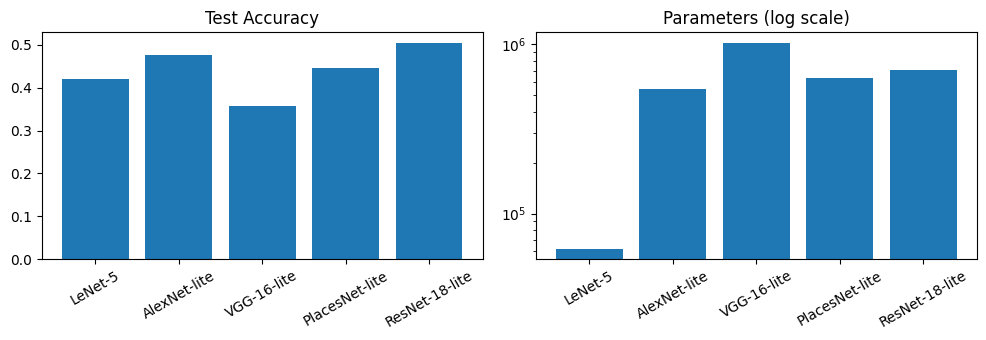

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

ax[0].bar(
    names,
    [results[n]["acc"] for n in names]
)
ax[0].set_title("Test Accuracy")

ax[1].bar(
    names,
    [results[n]["params"] for n in names]
)
ax[1].set_yscale("log")
ax[1].set_title("Parameters (log scale)")

for a in ax:
    a.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("comparison.png")
plt.show()

### My results (CIFAR-10, 10,000 train images, 2,000 test images, 4 epochs)

| Network | Parameters | Time (s) | Test accuracy |
|---|---:|---:|---:|
| LeNet-5 | 62,006 | 3 | 0.421 |
| AlexNet-lite | 543,946 | 3 | 0.475 |
| VGG-16-lite | 1,024,282 | 5 | 0.357 |
| PlacesNet-lite | 635,181 | 3 | 0.446 |
| ResNet-18-lite | 701,466 | 8 | 0.504 |

These are from a single run with one seed on a small subset and only 4 epochs, so exact values vary from run to run and are lower than the manual's typical values. Only the large gaps matter: ResNet-18-lite is best, and LeNet-5 is by far the smallest.

## **Explanation round**

**1. Highest accuracy vs best for its size:**
- Highest accuracy: **ResNet-18-lite** (0.504).
- Best accuracy for its size: **LeNet-5** (0.421 with only 62k parameters, roughly 10× more accuracy per parameter than the others).
- They are **not** the same network.

**2. AlexNet-lite (0.475) vs PlacesNet-lite (0.446):** they are the same network except for the size of the last layer, so on the same data they should score about the same. The gap is noise (random initialisation, slower start from the 355 unused outputs), not architecture. It also shows that small differences in a single run should not be over-read.

**3. Input 56, kernel 5, stride 2, padding 2:**
- Output size = ⌊(56 + 4 − 5)/2⌋ + 1 = ⌊27.5⌋ + 1 = **28**.
- Parameters for 64 → 128 channels = (5·5·64 + 1) × 128 = 1,601 × 128 = **204,928**.

**4. Full-size networks ordered by parameters:**

| Network | Parameters | Where they sit |
|---|---:|---|
| VGG-16 | 138.4M | 89% in FC layers (first FC layer alone 102.8M) |
| AlexNet | 62.4M | 94% in FC layers |
| PlacesNet | 59.8M | about 94% in FC layers (same body as AlexNet) |
| ResNet-18 | 11.7M | mostly in convolutions, especially stage 4 (about 8.4M); FC only 0.5M |
| LeNet-5 | 62k | mostly in the C5 convolution (48k) |

**5. One problem each network solved, and one it left open:**

| Network | Solved | Left open |
|---|---|---|
| LeNet-5 | End-to-end learning of features with shared weights | Too small for colour photos (about 42% here) |
| AlexNet | Training a large CNN at scale (ReLU, dropout, GPU) | Huge FC head (94% of weights) |
| VGG-16 | Depth through a simple, uniform 3×3 design | 138M parameters, heavy compute, hard to train without BatchNorm |
| PlacesNet | Scene recognition, by changing the data and output classes | Needs a huge labelled dataset; inherits AlexNet's big head |
| ResNet-18 | Vanishing gradients in very deep networks, with a small head | Still deep and compute-heavy for tiny devices |

**6. Network for a phone:** **ResNet-18 (lite)**. It gave the best accuracy in my run (0.504) with a small model (0.7M parameters; 11.7M at full size) because it has no large FC head. If the limits were extreme, LeNet-5 would work but it is only about 42% accurate here. AlexNet (about 250 MB) and VGG-16 (about 550 MB) are far too large for a phone.